In [1]:
from xenonnt_plot_style import XENONPlotStyle as xps
xps.use('xenonnt')

In [2]:
import os
import re
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid
from scipy.signal import savgol_filter
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt

In [3]:
def read_rga_file(filename):
    masses = None
    data_start_line = None

    with open(filename, 'r') as f:
        for line_number, line in enumerate(f):
            if 'Elapsed Time (s)' in line:
                masses = [int(x) for x in re.findall(r'Mass\s+(\d+)', line)]
                data_start_line = line_number + 1
                break

    if masses is None:
        raise ValueError('Could not find data header.')

    data = np.loadtxt(
        filename,
        delimiter=',',
        skiprows=data_start_line
    )

    if data.ndim == 1:
        data = data[np.newaxis, :]

    if data.shape[1] != len(masses) + 1:
        raise ValueError('Number of columns does not match number of masses.')

    result = {'t': data[:, 0]}

    for i, mass in enumerate(masses):
        result[mass] = data[:, i + 1]

    return result

In [4]:
def get_t0(
    x,
    y,
    slope_window=7,
    slope_fraction=0.05,
    min_rise_dex=0.12,
    max_gap=2,
    baseline_points=8,
    onset_fraction=0.05,
    debug=False,
):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y) & (y > 0)
    x = x[mask]
    y = y[mask]

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    z = median_filter(np.log10(y), size=3, mode='nearest')

    n = len(x)

    if slope_window % 2 == 0:
        slope_window += 1

    h = slope_window // 2

    slope = np.full(n, np.nan)

    for i in range(h, n - h):
        xx = x[i-h:i+h+1]
        zz = z[i-h:i+h+1]

        xm = np.mean(xx)

        slope[i] = (
            np.sum((xx - xm) * (zz - np.mean(zz)))
            / np.sum((xx - xm)**2)
        )

    imax = np.argmax(z)

    valid_slope = slope[h:imax]

    median_slope = np.nanmedian(valid_slope)

    slope_noise = (
        1.4826
        * np.nanmedian(
            np.abs(valid_slope - median_slope)
        )
    )

    max_slope = np.nanmax(valid_slope)

    slope_threshold = max(
        5.0 * slope_noise,
        slope_fraction * max_slope,
    )

    active = slope > slope_threshold
    active[imax:] = False

    indices = np.where(active)[0]

    if len(indices) == 0:
        raise ValueError('No significant rising region found.')

    runs = []

    start = indices[0]
    previous = indices[0]

    for i in indices[1:]:
        if i - previous <= max_gap + 1:
            previous = i
        else:
            runs.append((start, previous))
            start = i
            previous = i

    runs.append((start, previous))

    good_runs = []

    for start, end in runs:
        i1 = max(0, start - h)
        i2 = min(imax, end + h)

        rise = z[i2] - z[i1]

        if rise >= min_rise_dex:
            good_runs.append((start, end))

    if len(good_runs) == 0:
        raise ValueError('No significant sustained rise found.')

    rise_start, rise_end = good_runs[-1]

    b1 = max(0, rise_start - baseline_points)
    b2 = max(b1 + 1, rise_start - 1)

    baseline = np.median(z[b1:b2])
    peak = z[imax]

    target = (
        baseline
        + onset_fraction * (peak - baseline)
    )

    search_start = max(0, rise_start - h - 3)

    crossing = np.where(
        (z[search_start:imax] <= target)
        & (z[search_start+1:imax+1] > target)
    )[0]

    if len(crossing) == 0:
        t0 = x[rise_start]
    else:
        i = search_start + crossing[0]

        t0 = (
            x[i]
            + (target - z[i])
            * (x[i+1] - x[i])
            / (z[i+1] - z[i])
        )

    if debug:
        plt.figure()

        plt.semilogy(x, y)
        plt.axvline(t0, ls='--', label=f't0 = {t0:.1f} s')
        plt.axvline(x[imax], ls=':', label='maximum')

        plt.xlabel('Time [s]')
        plt.ylabel('Partial Pressure [Torr]')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return t0

In [5]:
def get_integral(x, y):
    xmin, xmax = -10, 250

    mask = (x > xmin) & (x < xmax)
    
    xx = np.r_[xmin, x[mask], xmax]
    yy = np.interp(xx, x, y)
    
    integral = trapezoid(yy, xx)
    return integral

In [6]:
folder = '../../Documents/RGAData/PressurevsTime'

filenames = [
    # 'PressurevsTime-20260915-093220-567.txt',
    # 'PressurevsTime-20260915-115921-106.txt',
    # 'PressurevsTime-20260915-140737-709.txt',
    # 'PressurevsTime-20260915-145243-305.txt',
    # 'PressurevsTime-20260915-154851-381.txt',
    'PressurevsTime-20260916-163615-635.txt',
    'PressurevsTime-20260918-153328-563.txt',
    'PressurevsTime-20260921-112513-241.txt',
    'PressurevsTime-20260921-155319-558.txt',
]

masses = [87, 28, 40, 62, 84]

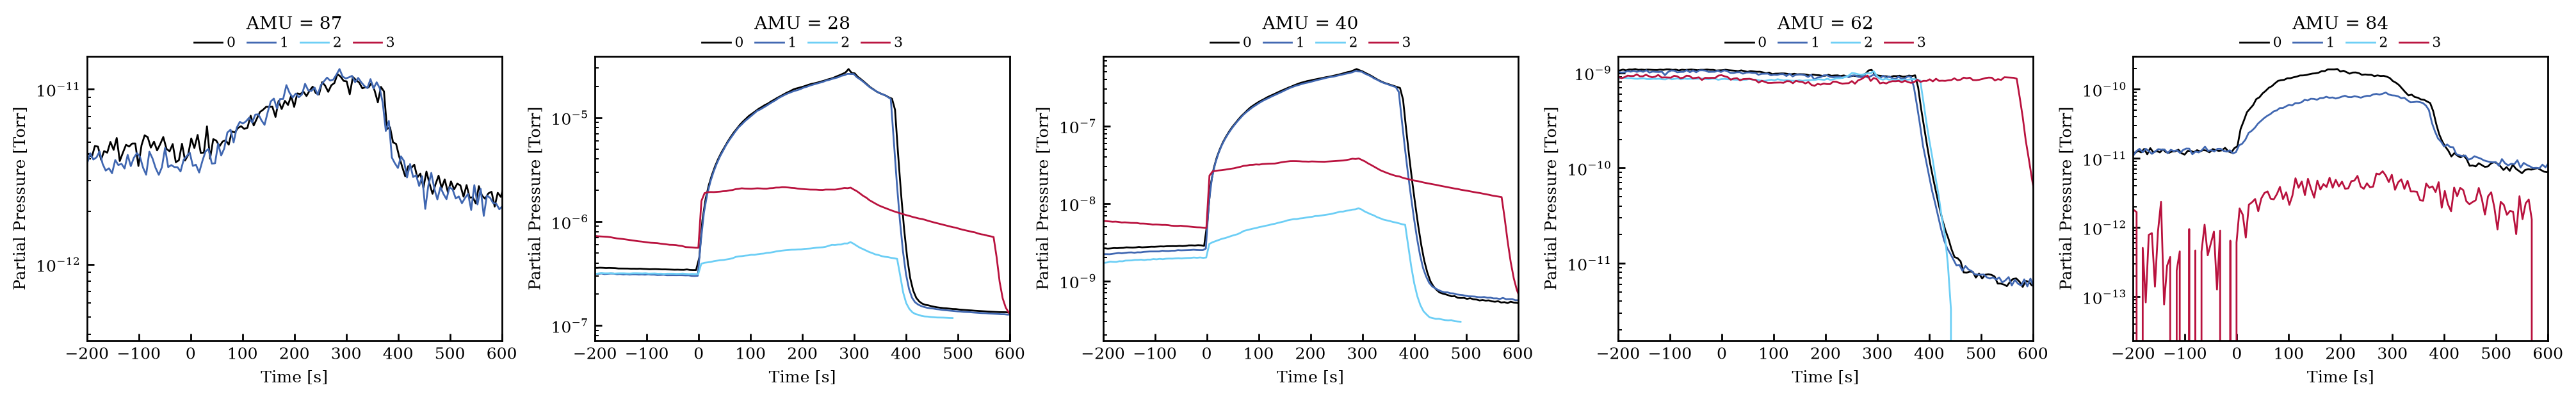

In [7]:
fig, axes = plt.subplots(1, len(masses), figsize=(4 * len(masses), 3))

for i, (ax, mass) in enumerate(zip(axes, masses)):
    for j, filename in enumerate(filenames):
        rga = read_rga_file(os.path.join(folder, filename))
        # filename.split('-')[2]
        t0 = get_t0(rga['t'], rga[28])
        ax.plot(rga['t'] - t0, rga[mass], label=j)
    
    ax.legend(title=f'AMU = {mass}', ncols=len(filenames))
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Partial Pressure [Torr]')
    ax.set_yscale('log')
    ax.set_xlim(-200, 600)
    
plt.show()

In [8]:
integrals = np.empty((len(filenames), len(masses)))

for i, filename in enumerate(filenames):
    rga = read_rga_file(os.path.join(folder, filename))
    t0 = get_t0(rga['t'], rga[28])
    for j, mass in enumerate(masses):
        integrals[i, j] = get_integral(rga['t'] - t0, rga[mass])

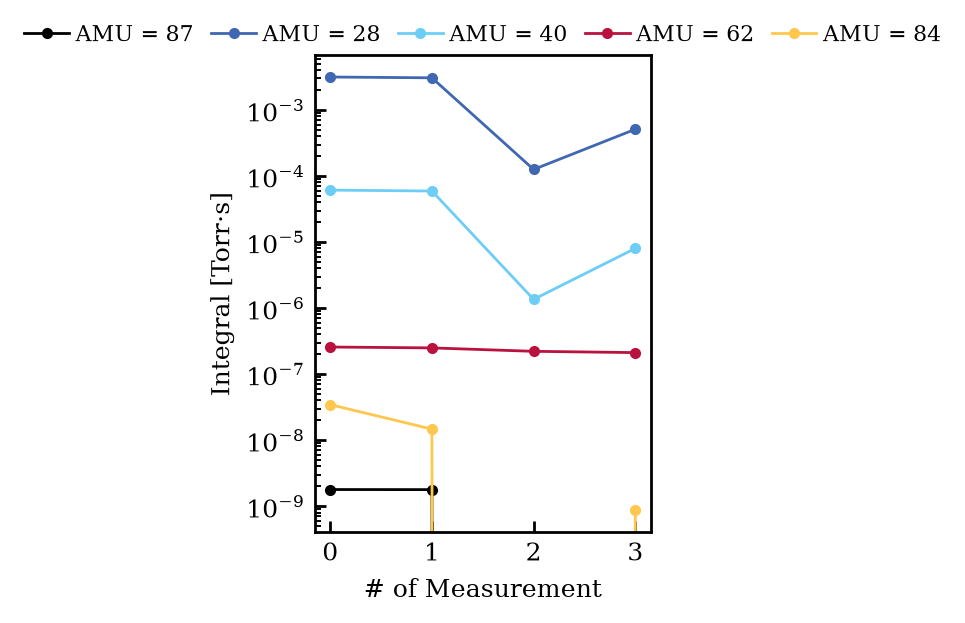

In [9]:
fig, ax = plt.subplots(figsize=(4, 3))

for j, mass in enumerate(masses):
    ax.plot(np.arange(len(filenames)), integrals[:, j], marker='o', label=f'AMU = {mass}')

ax.legend(ncols=len(masses))
ax.set_xlabel('# of Measurement')
ax.set_ylabel('Integral [Torr$\cdot$s]')
ax.set_yscale('log')
ax.set_xticks(np.arange(len(filenames)))

plt.show()

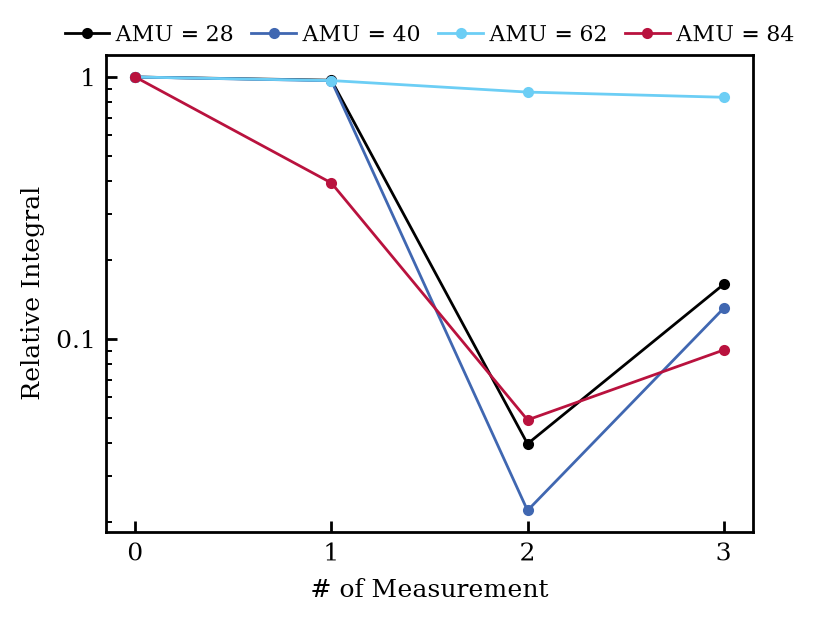

In [10]:
fig, ax = plt.subplots(figsize=(4, 3))

for j, mass in enumerate(masses):
    if j == 0:
        continue
    ax.plot(
        np.arange(len(filenames)),
        (integrals[:, j] - integrals[:, 0]) / (integrals[0, j] - integrals[0, 0]),
        marker='o',
        label=f'AMU = {mass}',
    )

ax.legend(ncols=len(masses) - 1)
ax.set_xlabel('# of Measurement')
ax.set_ylabel('Relative Integral')
ax.set_yscale('log')
ax.set_xticks(np.arange(len(filenames)))

plt.show()